# House Price Prediction Using Linear Regression

## Project Overview

This project focuses on predicting house prices using Linear Regression.

The dataset contains information about residential properties, including structural and location-related features. The objective is to understand how different factors influence house prices and build a machine learning model to predict the price of a house.

## Objectives

- Perform Exploratory Data Analysis (EDA)
- Understand the important factors affecting house prices
- Handle missing values and categorical variables
- Analyze correlations between features
- Select relevant features for prediction
- Build a Linear Regression model
- Evaluate the model using MSE, RMSE and R²
- Compare actual and predicted house prices
- Analyze model residuals and coefficients
- Draw meaningful conclusions from the model

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv("../dataset/house_prices_dataset.csv")

In [4]:
df.head()

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903


In [5]:
df.shape

(10000, 5)

In [6]:
df.columns

Index(['square_feet', 'num_rooms', 'age', 'distance_to_city(km)', 'price'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
 4   price                 10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB


In [8]:
df.isnull().sum()

square_feet             0
num_rooms               0
age                     0
distance_to_city(km)    0
price                   0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,square_feet,num_rooms,age,distance_to_city(km),price
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1999.147496,4.49510,49.516900,15.362148,263011.571609
std,501.021194,1.71116,28.992336,8.325101,98336.945117
min,500.000000,2.00000,0.000000,1.000161,-95613.138249
25%,1663.704735,3.00000,24.000000,8.121636,196791.510684
50%,1998.702512,4.00000,49.000000,15.403146,262497.361236
75%,2335.540444,6.00000,75.000000,22.447530,330445.581908
max,3963.118853,7.00000,99.000000,29.993892,660168.255648


In [13]:
df.dtypes

square_feet             float64
num_rooms                 int64
age                       int64
distance_to_city(km)    float64
price                   float64
dtype: object

In [14]:
df.columns

Index(['square_feet', 'num_rooms', 'age', 'distance_to_city(km)', 'price'], dtype='object')

In [15]:
df.shape

(10000, 5)

In [16]:
df.isnull().sum()

square_feet             0
num_rooms               0
age                     0
distance_to_city(km)    0
price                   0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

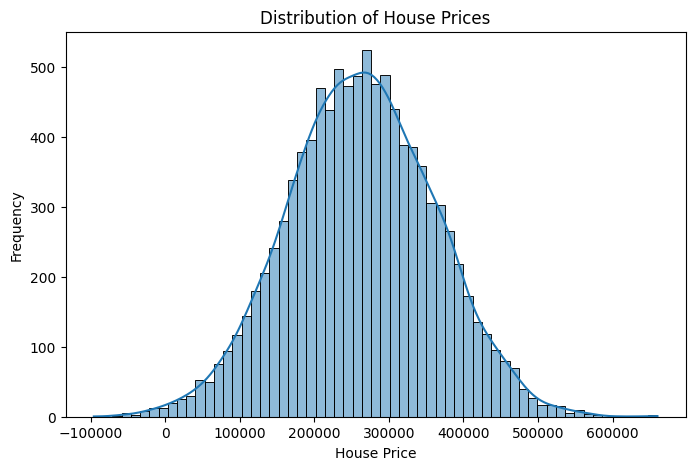

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(df['price'], kde=True)

plt.title('Distribution of House Prices')
plt.xlabel('House Price')
plt.ylabel('Frequency')

plt.show()

### Observation

The distribution of house prices shows how frequently different price ranges occur in the dataset. This helps us understand the spread and overall pattern of the target variable before building the prediction model.

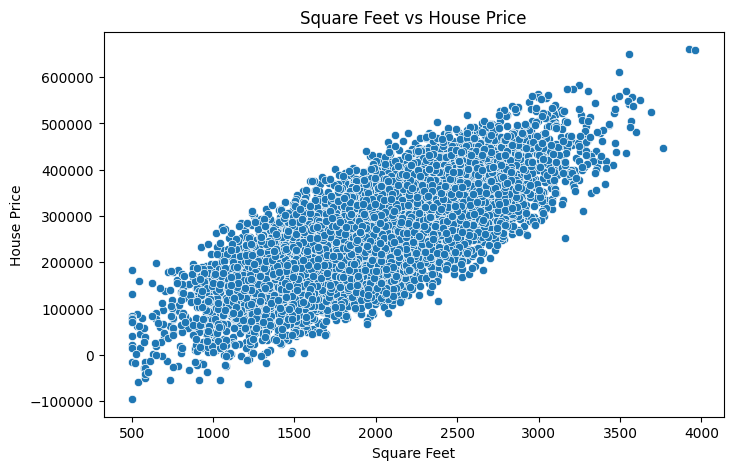

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='square_feet', y='price')

plt.title('Square Feet vs House Price')
plt.xlabel('Square Feet')
plt.ylabel('House Price')

plt.show()

### Observation

The scatter plot shows the relationship between house area and price. It helps identify whether larger houses tend to have different price levels and whether the relationship appears approximately linear.

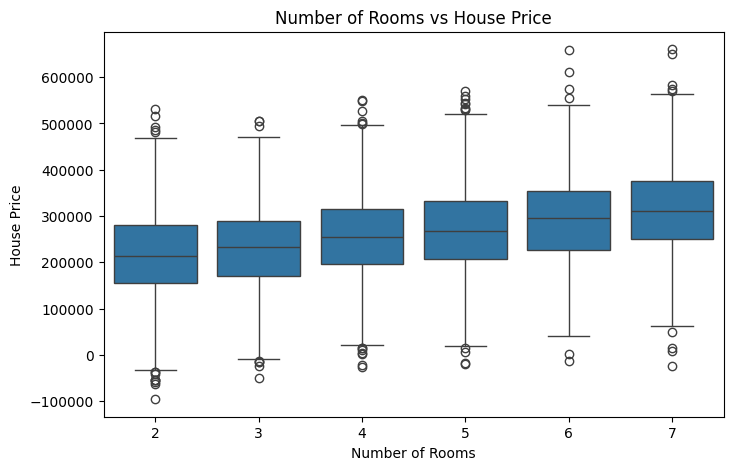

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='num_rooms', y='price')

plt.title('Number of Rooms vs House Price')
plt.xlabel('Number of Rooms')
plt.ylabel('House Price')

plt.show()

### Observation

The box plot compares house prices across different numbers of rooms. It helps identify differences in price distribution and possible variation among houses with different room counts.

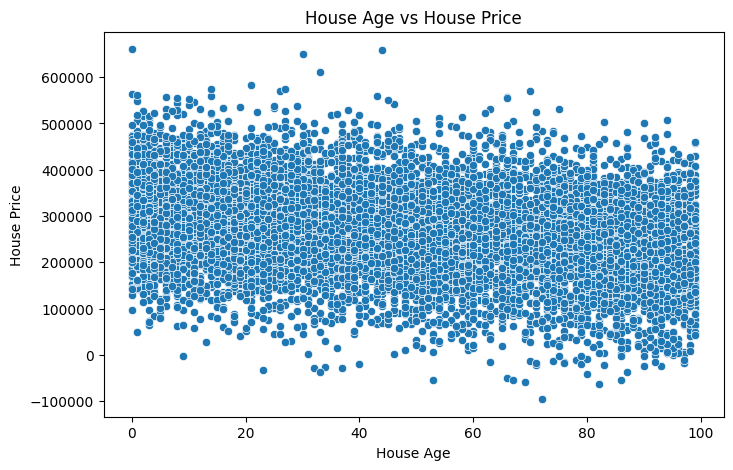

In [21]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='age', y='price')

plt.title('House Age vs House Price')
plt.xlabel('House Age')
plt.ylabel('House Price')

plt.show()

### Observation

The scatter plot shows the relationship between house age and price. It helps us examine whether house age is associated with changes in house prices.

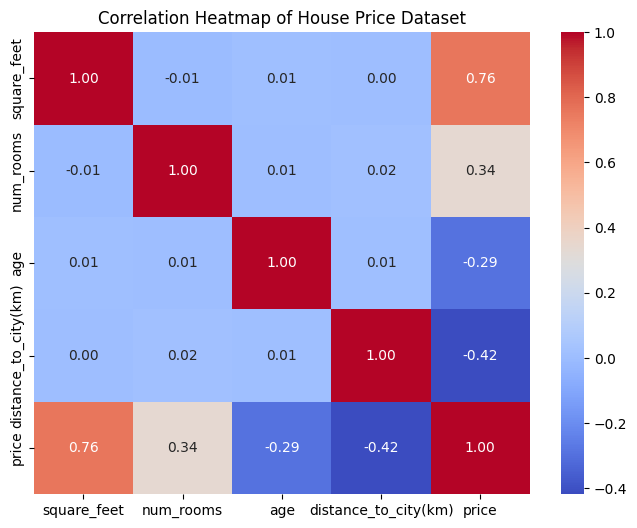

In [22]:
plt.figure(figsize=(8, 6))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of House Price Dataset')
plt.show()

### Observation

The correlation heatmap shows the strength and direction of the relationships between the numerical variables.

The correlation of each feature with `price` helps us understand which variables may be useful for predicting house prices. A positive correlation indicates that the variables tend to increase together, while a negative correlation indicates an inverse relationship.

## Feature Selection

The target variable for this project is `price`.

The independent features selected for prediction are:

- `square_feet` — represents the size of the house.
- `num_rooms` — represents the number of rooms.
- `age` — represents the age of the property.
- `distance_to_city(km)` — represents the property's distance from the city.

These features are selected because they represent measurable characteristics of a property that may have a relationship with its selling price.

Since the dataset contains only numerical features, One-Hot Encoding is not required. All selected features can be directly used by the Linear Regression model.

In [25]:
X = df.drop('price', axis=1)
y = df['price']

In [26]:
X.head()

,square_feet,num_rooms,age,distance_to_city(km)
0,2248.357077,3,92,22.997972
1,1930.867849,2,22,13.984254
2,2323.844269,6,33,21.500945
3,2761.514928,3,63,10.343638
4,1882.923313,7,54,25.485200


In [27]:
y.head()

0    200374.090410
1    268784.847337
2    315020.857676
3    355111.468459
4    234197.123903
Name: price, dtype: float64

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [29]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 4)
Testing data: (2000, 4)


In [30]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
print("Model training completed successfully.")

Model training completed successfully.


In [32]:
y_pred = model.predict(X_test)

In [33]:
y_pred[:10]

array([316636.89860441, 245793.09538071, 222084.4079465 , 231463.17523019,
       378538.87517034, 126495.38114013, 247179.1466624 , 203474.02453475,
       248667.62294848, 204065.27073993])

In [34]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 386443817.4602803
Root Mean Squared Error (RMSE): 19658.174316560537
R² Score: 0.960063695761787


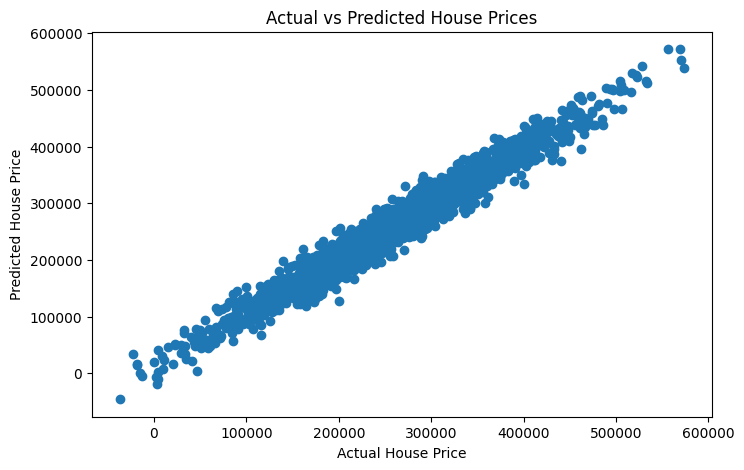

In [35]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual vs Predicted House Prices')

plt.show()

### Observation

The scatter plot compares the actual house prices with the prices predicted by the Linear Regression model.

Points closer to the diagonal relationship between actual and predicted values indicate predictions that are closer to the actual prices.

In [36]:
residuals = y_test - y_pred

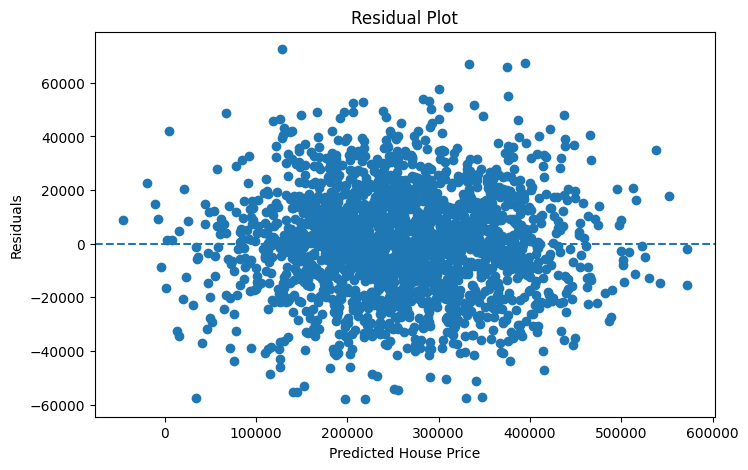

In [37]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted House Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

### Observation

The residual plot shows the difference between the actual and predicted house prices.

Residuals are calculated as:

Residual = Actual Price − Predicted Price

The plot helps identify whether there are systematic patterns or unusual observations in the model's prediction errors.

In [38]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,square_feet,149.792468
1,num_rooms,20113.477779
2,age,-1003.402669
3,distance_to_city(km),-5011.960211


In [39]:
coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
1,num_rooms,20113.477779
0,square_feet,149.792468
2,age,-1003.402669
3,distance_to_city(km),-5011.960211


## Coefficient Analysis

The Linear Regression coefficients indicate the estimated change in house price associated with a one-unit change in a feature, while keeping the other features constant.

A positive coefficient indicates a positive relationship with predicted price, while a negative coefficient indicates a negative relationship.

The magnitude of a coefficient should be interpreted in the context of the feature's measurement unit.

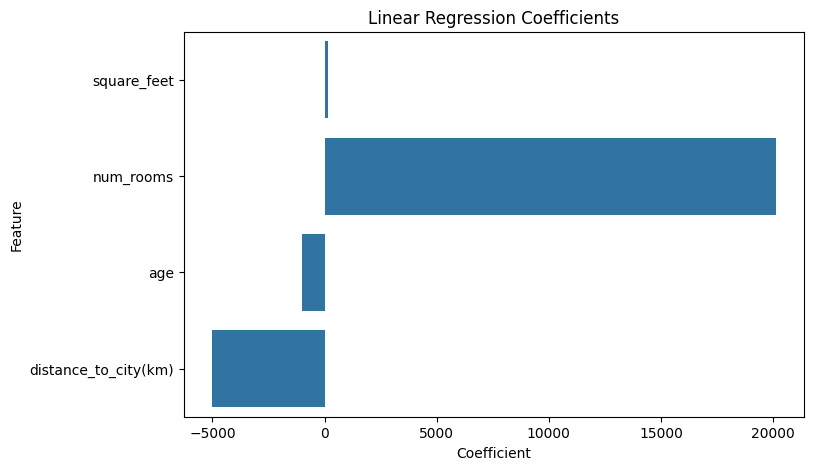

In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=coefficients,
    x='Coefficient',
    y='Feature'
)

plt.title('Linear Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.show()

In [41]:
from sklearn.linear_model import Ridge, Lasso

In [42]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("R² Score:", ridge_r2)

Ridge Regression
MSE: 386442853.00556815
RMSE: 19658.149785917496
R² Score: 0.9600637954315321


In [43]:
lasso_model = Lasso(alpha=1.0)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression")
print("MSE:", lasso_mse)
print("RMSE:", lasso_rmse)
print("R² Score:", lasso_r2)

Lasso Regression
MSE: 386443423.7464805
RMSE: 19658.164302560923
R² Score: 0.9600637364493937


In [44]:
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'MSE': [
        mse,
        ridge_mse,
        lasso_mse
    ],
    'RMSE': [
        rmse,
        ridge_rmse,
        lasso_rmse
    ],
    'R2 Score': [
        r2,
        ridge_r2,
        lasso_r2
    ]
})

model_comparison

,Model,MSE,RMSE,R2 Score
0,Linear Regression,3.864438e+08,19658.174317,0.960064
1,Ridge Regression,3.864429e+08,19658.149786,0.960064
2,Lasso Regression,3.864434e+08,19658.164303,0.960064


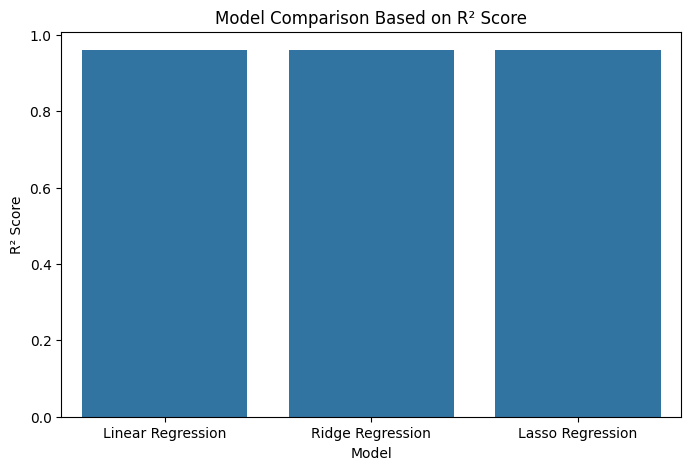

In [45]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison,
    x='Model',
    y='R2 Score'
)

plt.title('Model Comparison Based on R² Score')
plt.xlabel('Model')
plt.ylabel('R² Score')

plt.show()

### Observation

The model comparison shows the R² score obtained by Linear Regression, Ridge Regression and Lasso Regression.

The models can be compared using their evaluation metrics. Higher R² indicates that the model explains more variation in the target variable, while lower RMSE indicates smaller prediction error.

## Key Findings

- House price prediction was performed using Linear Regression.
- The dataset was explored using descriptive statistics and visualizations.
- The relationships between house features and price were examined using scatter plots and correlation analysis.
- The dataset contains numerical features such as square feet, number of rooms, house age and distance from the city.
- The data was divided into training and testing sets using an 80:20 ratio.
- Linear Regression was evaluated using MSE, RMSE and R² Score.
- Actual versus predicted prices and residuals were analyzed to understand model performance.
- Regression coefficients were examined to understand the relationship between the input features and predicted house price.
- Ridge and Lasso Regression were additionally implemented for comparison.

## Conclusion

This project demonstrated the complete workflow for predicting house prices using regression techniques.

Exploratory Data Analysis helped in understanding the characteristics of the dataset and relationships between the variables. A Linear Regression model was trained using property-related features and evaluated using MSE, RMSE and R² Score.

Residual analysis and coefficient analysis provided additional understanding of the model's prediction errors and feature relationships. Ridge and Lasso Regression were also tested as regularized alternatives.

The results demonstrate how machine learning regression techniques can be applied to estimate house prices from available property characteristics.

In [46]:
model_comparison.to_csv(
    "../output/model_comparison.csv",
    index=False
)

In [47]:
predictions = pd.DataFrame({
    'Actual_Price': y_test.values,
    'Predicted_Price': y_pred
})

predictions.to_csv(
    "../output/house_price_predictions.csv",
    index=False
)

In [48]:
coefficients.to_csv(
    "../output/linear_regression_coefficients.csv",
    index=False
)

In [49]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nModel Performance:")
print(model_comparison)

print("\nOutput files created successfully.")

Missing values:
square_feet             0
num_rooms               0
age                     0
distance_to_city(km)    0
price                   0
dtype: int64

Duplicate rows:
0

Model Performance:
               Model           MSE          RMSE  R2 Score
0  Linear Regression  3.864438e+08  19658.174317  0.960064
1   Ridge Regression  3.864429e+08  19658.149786  0.960064
2   Lasso Regression  3.864434e+08  19658.164303  0.960064

Output files created successfully.
